# Individuell uppgift – Hälsostudie (Del 2)

I den här notebooken fortsätter jag analysen från Del 1. 
Jag flyttar över delar av koden till funktioner och en klass, och testar även en enkel linjär regression.

In [7]:
from health_analysis import load_health_data, HealthAnalyzer

df = load_health_data("data/health_study_dataset.csv")
analyzer = HealthAnalyzer(df)

df.head()


,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


### Beskrivande statistik via HealthAnalyzer

Här använder jag klassen `HealthAnalyzer` för att beräkna samma typ av beskrivande
statistik som i Del 1, men nu ligger koden i en modul och kan återanvändas enklare.


In [8]:
analyzer.summary_stats()


,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


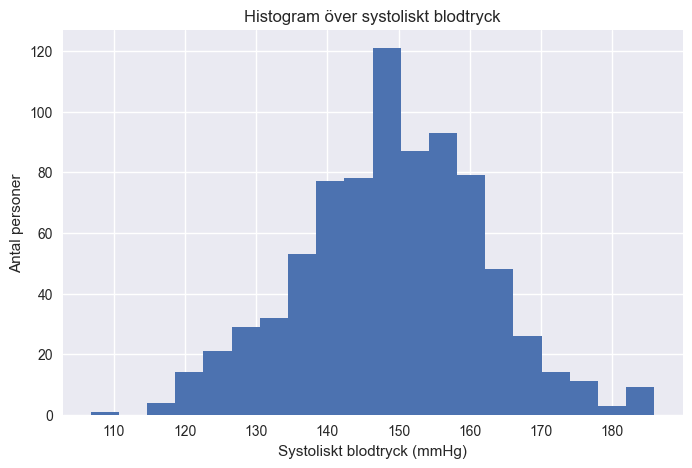

In [9]:
analyzer.plot_bp_hist()


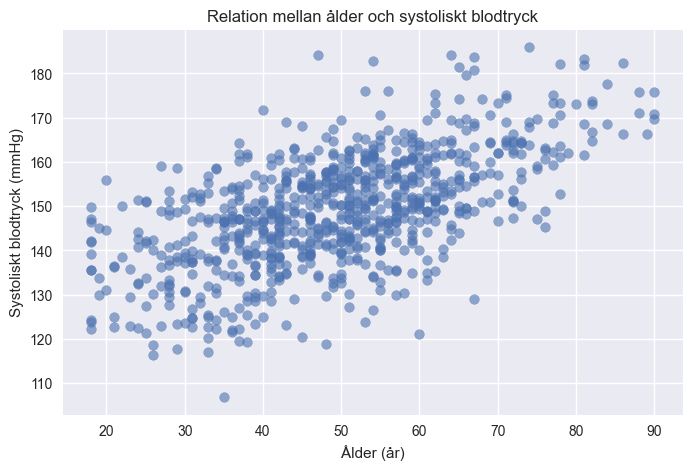

In [10]:
analyzer.plot_bp_vs_age()


### Relation mellan ålder och systoliskt blodtryck

Denna graf visar sambandet mellan deltagarnas ålder och deras systoliska blodtryck.
Punkterna ligger spritt men det finns en tendens att blodtrycket ökar något med åldern.


### Linjär regression: blodtryck ~ ålder + vikt

Här använder jag en enkel linjär regression för att modellera systoliskt blodtryck
som en funktion av ålder och vikt.

Modellen kan skrivas ungefär som:

systolic_bp = a * age + b * weight + c


- Koefficienterna visar hur mycket blodtrycket i genomsnitt förändras när ålder eller vikt ökar.
- R²-värdet visar hur stor del av variationen i blodtryck som modellen kan förklara.


In [11]:
model, r2 = analyzer.bp_regression()

print("Koefficienter (age, weight):", model.coef_)
print("Intercept:", model.intercept_)
print("R^2:", round(r2, 3))


Koefficienter (age, weight): [0.53892763 0.17765752]
Intercept: 109.49908144566375
R^2: 0.405


Här ser vi att både ålder och vikt har positiva koefficienter, vilket betyder att högre ålder och vikt hänger ihop med högre systoliskt blodtryck i den här modellen. R²-värdet runt 0.40 betyder att modellen förklarar ungefär 40 % av variationen i blodtrycket.
